#1)Problem statement:
The goal of this project is to predict whether a user will purchase a product based on social network advertisement data.

The dataset used in this project is Social_Network_Ads, which contains the columns User ID, Gender, Age, EstimatedSalary, and Purchased. The Purchased column is the target variable.

A machine learning model is built to predict whether a user will purchase the product based on features like Age and EstimatedSalary.

#2)Import Libraries:

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#3)Load Dataset:

In [3]:
df=pd.read_csv("/content/Social_Network_Ads.csv")

In [4]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


#4)Feature Selection:

In [5]:
df.drop("User ID",axis=1,inplace=True)

In [6]:
df

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


#5)Handle Missing Values (NaNs):

In [7]:
df.isna().sum()

,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


#6)Remove Errors / Data Cleaning:

In [8]:
df.dtypes

,0
Gender,object
Age,int64
EstimatedSalary,int64
Purchased,int64


<Axes: >

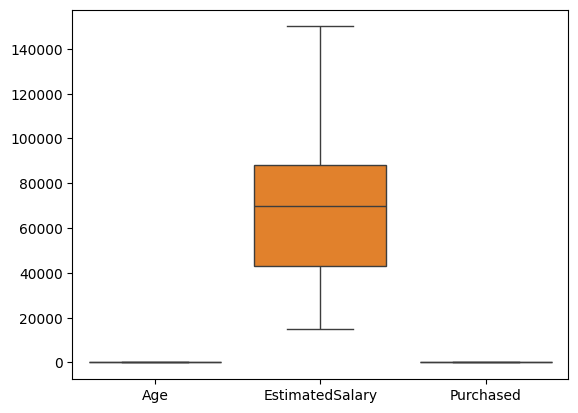

In [9]:
sns.boxplot(df)

#7)Encoding Categorical Data:

In [10]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [11]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [12]:
df["Gender"]=df["Gender"].map({"Male":1,"Female":0})

In [13]:
df

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0
...,...,...,...,...
395,0,46,41000,1
396,1,51,23000,1
397,0,50,20000,1
398,1,36,33000,0


#8)Separate Features and Target:

In [14]:
X=df.drop("Purchased",axis=1)

In [15]:
X.shape

(400, 3)

In [16]:
y=df["Purchased"]

In [17]:
y.shape

(400,)

#9)Heading for Imbalanced Data:

In [18]:
y.value_counts()

,count
Purchased,
0,257
1,143


<Axes: ylabel='count'>

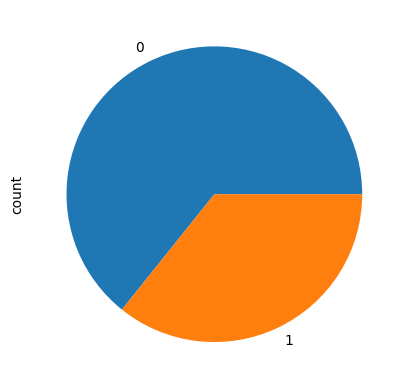

In [19]:
y.value_counts().plot(kind="pie")

In [20]:
from imblearn.over_sampling import  RandomOverSampler

In [21]:
ros=RandomOverSampler()

In [22]:
x_ros,y_ros=ros.fit_resample(X,y)

In [23]:
y_ros.value_counts()

,count
Purchased,
0,257
1,257


<Axes: ylabel='count'>

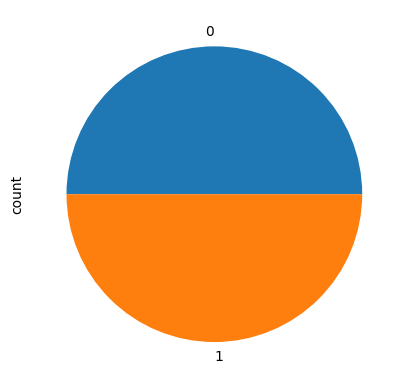

In [24]:
y_ros.value_counts().plot(kind="pie")

#10)Train-Test Split:

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x_ros,y_ros,test_size=0.20,random_state=129)

In [27]:
x_train.shape,x_test.shape

((411, 3), (103, 3))

In [28]:
y_train.shape,y_test.shape

((411,), (103,))

#11)Build and Train Model:

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
lr_model=LogisticRegression()

In [32]:
lr_model

LogisticRegression()

In [33]:
lr_model.fit(x_train,y_train)

LogisticRegression()

#12)Model Evaluation:

In [34]:
lr_model.score(x_test,y_test)

0.941747572815534

#Auto Random State:

In [36]:
lst=[]
for i in range(1000):
    x_train,x_test,y_train,y_test=train_test_split(x_ros,y_ros,test_size=0.20,random_state=i)
    lr_model=LogisticRegression()
    m=lr_model.fit(x_train,y_train)
    s=lr_model.score(x_test,y_test)
    lst.append(s)
print(max(lst), lst.index(max(lst)))

0.941747572815534 129


#Conclusion:
In this project, the Social_Network_Ads dataset was used to predict user purchasing behavior. Data preprocessing steps such as removing missing values, fixing errors, encoding categorical data, and separating features and target variables were performed.

The dataset was divided into training and testing sets, and a Logistic Regression model was trained on the data. The model achieved an accuracy score of 91%, which shows that it can effectively predict whether a user will purchase the product based on the given features.